In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
df = pd.read_csv(r"C:\Users\SAIM\Downloads\sales_data.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 1200 rows, 14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrderID,1200,1200,ORD200000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1200,671,2023-08-20,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,1200,1189,C38840,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1200,7,Printer,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1200.0,NaN,NaN,NaN,2.945833,1.407557,1.0,2.0,3.0,4.0,5.0
UnitPrice,1200.0,NaN,NaN,NaN,356.41275,197.177146,11.39,186.0625,364.21,521.57,699.93
ShippingAddress,1200,655,533 Main St,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,1200,5,Online,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderStatus,1200,5,Cancelled,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackingNumber,1200,1200,TRK37947903,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
quality_report = quality_report[quality_report['Missing Count'] > 0]
print("Columns with missing values:")
print(quality_report if not quality_report.empty else "None found.")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate OrderIDs: {df['OrderID'].duplicated().sum()}")

Columns with missing values:
            Missing Count  Missing %
CouponCode            309      25.75

Duplicate rows: 0
Duplicate OrderIDs: 0


In [7]:
# CouponCode is missing when no coupon was applied at checkout — this is
# expected/legitimate missingness, not corrupted data. We label it explicitly.
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
print("CouponCode nulls replaced with 'No Coupon'.")
df['CouponCode'].value_counts()

CouponCode nulls replaced with 'No Coupon'.


CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [8]:
# Convert Date column to proper datetime type for trend analysis
df['Date'] = pd.to_datetime(df['Date'])

# Derive useful time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b')
df['DayOfWeek'] = df['Date'].dt.day_name()

print(f"Date range: {df['Date'].min().date()}  to  {df['Date'].max().date()}")
df[['OrderID', 'Date', 'Year', 'Month', 'DayOfWeek']].head()

Date range: 2023-01-01  to  2025-06-30


,OrderID,Date,Year,Month,DayOfWeek
0,ORD200000,2023-01-04,2023,1,Wednesday
1,ORD200001,2024-08-23,2024,8,Friday
2,ORD200002,2024-02-27,2024,2,Tuesday
3,ORD200003,2023-10-15,2023,10,Sunday
4,ORD200004,2025-05-08,2025,5,Thursday


In [9]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

stats_summary = pd.DataFrame({
    'Count': df[numeric_cols].count(),
    'Mean': df[numeric_cols].mean().round(2),
    'Median': df[numeric_cols].median().round(2),
    'Std Dev': df[numeric_cols].std().round(2),
    'Min': df[numeric_cols].min(),
    'Max': df[numeric_cols].max()
})
stats_summary

,Count,Mean,Median,Std Dev,Min,Max
Quantity,1200,2.95,3.00,1.41,1.00,5.00
UnitPrice,1200,356.41,364.21,197.18,11.39,699.93
ItemsInCart,1200,5.48,5.00,2.28,1.00,10.00
TotalPrice,1200,1053.97,823.62,819.86,11.39,3456.40


In [10]:
# Compare Mean vs Median to spot skew at a glance
for col in numeric_cols:
    mean_v, median_v = df[col].mean(), df[col].median()
    skew_note = "Right-skewed (mean > median)" if mean_v > median_v * 1.05 else \
                "Left-skewed (mean < median)" if mean_v < median_v * 0.95 else "Roughly symmetric"
    print(f"{col:12s} | Mean: {mean_v:9.2f} | Median: {median_v:9.2f} | {skew_note}")

Quantity     | Mean:      2.95 | Median:      3.00 | Roughly symmetric
UnitPrice    | Mean:    356.41 | Median:    364.21 | Roughly symmetric
ItemsInCart  | Mean:      5.49 | Median:      5.00 | Right-skewed (mean > median)
TotalPrice   | Mean:   1053.97 | Median:    823.62 | Right-skewed (mean > median)


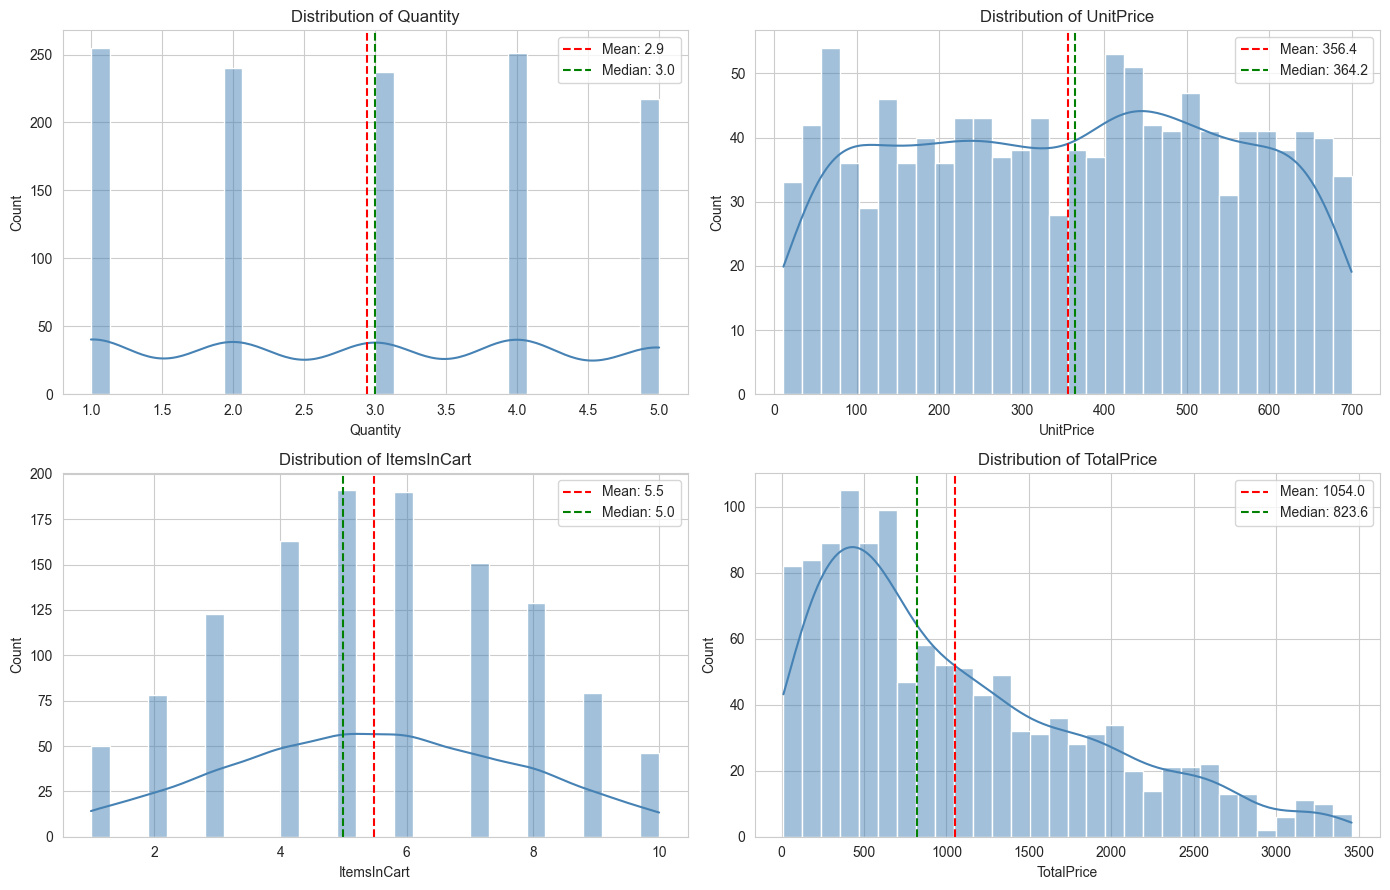

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color='steelblue')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

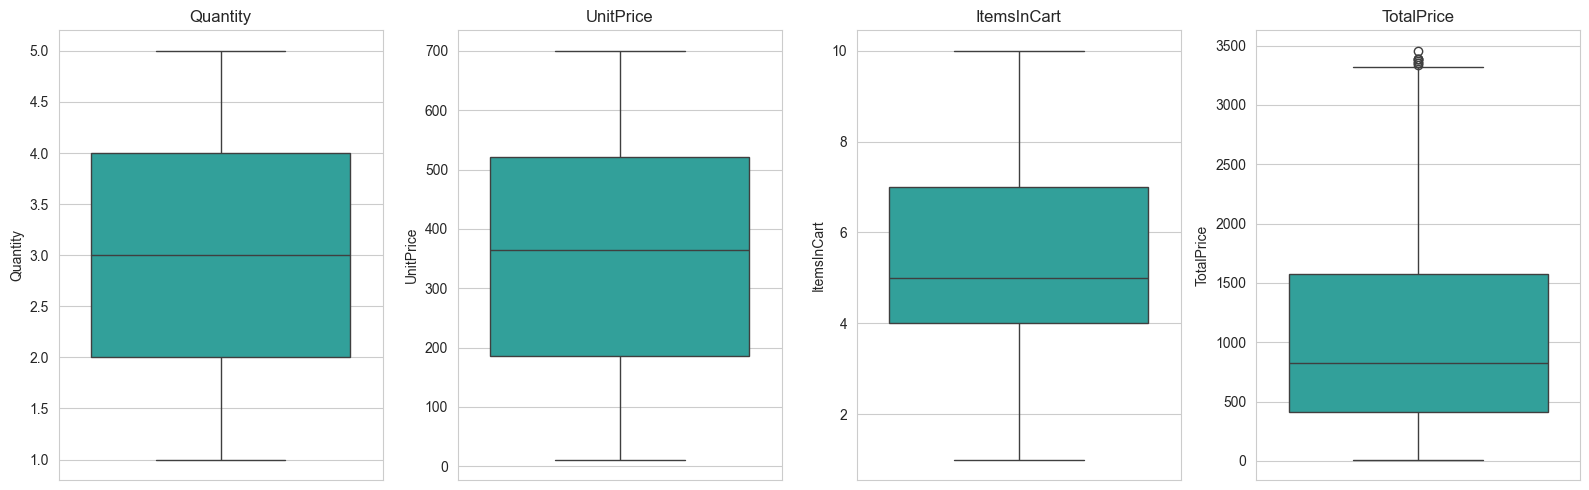

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightseagreen')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [13]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)], lower, upper

outlier_report = {}
for col in numeric_cols:
    outliers, low, high = detect_outliers_iqr(df[col])
    outlier_report[col] = len(outliers)
    print(f"{col:12s} | Valid range: [{low:8.2f}, {high:8.2f}] | Outliers found: {len(outliers)}")

pd.Series(outlier_report, name='Outlier Count').to_frame()

Quantity     | Valid range: [   -1.00,     7.00] | Outliers found: 0
UnitPrice    | Valid range: [ -317.20,  1024.83] | Outliers found: 0
ItemsInCart  | Valid range: [   -0.50,    11.50] | Outliers found: 0
TotalPrice   | Valid range: [-1341.41,  3330.41] | Outliers found: 8


,Outlier Count
Quantity,0
UnitPrice,0
ItemsInCart,0
TotalPrice,8


In [14]:
# Inspect the actual outlier rows for TotalPrice (highest business relevance)
outliers_totalprice, low, high = detect_outliers_iqr(df['TotalPrice'])
df.loc[outliers_totalprice.index].sort_values('TotalPrice', ascending=False).head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,MonthName,DayOfWeek
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40,2023,8,Aug,Thursday
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,No Coupon,Facebook,3390.95,2023,6,Jun,Wednesday
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80,2023,5,May,Tuesday
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90,2023,11,Nov,Sunday
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20,2023,2,Feb,Tuesday
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75,2023,3,Mar,Monday
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40,2024,7,Jul,Monday
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00,2023,10,Oct,Monday


C:\Users\SAIM\AppData\Local\Temp\ipykernel_16184\948166386.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='viridis')
C:\Users\SAIM\AppData\Local\Temp\ipykernel_16184\948166386.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='viridis')
C:\Users\SAIM\AppData\Local\Temp\ipykernel_16184\948166386.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='viridis')
C:\Users\SAIM\AppData\Local\

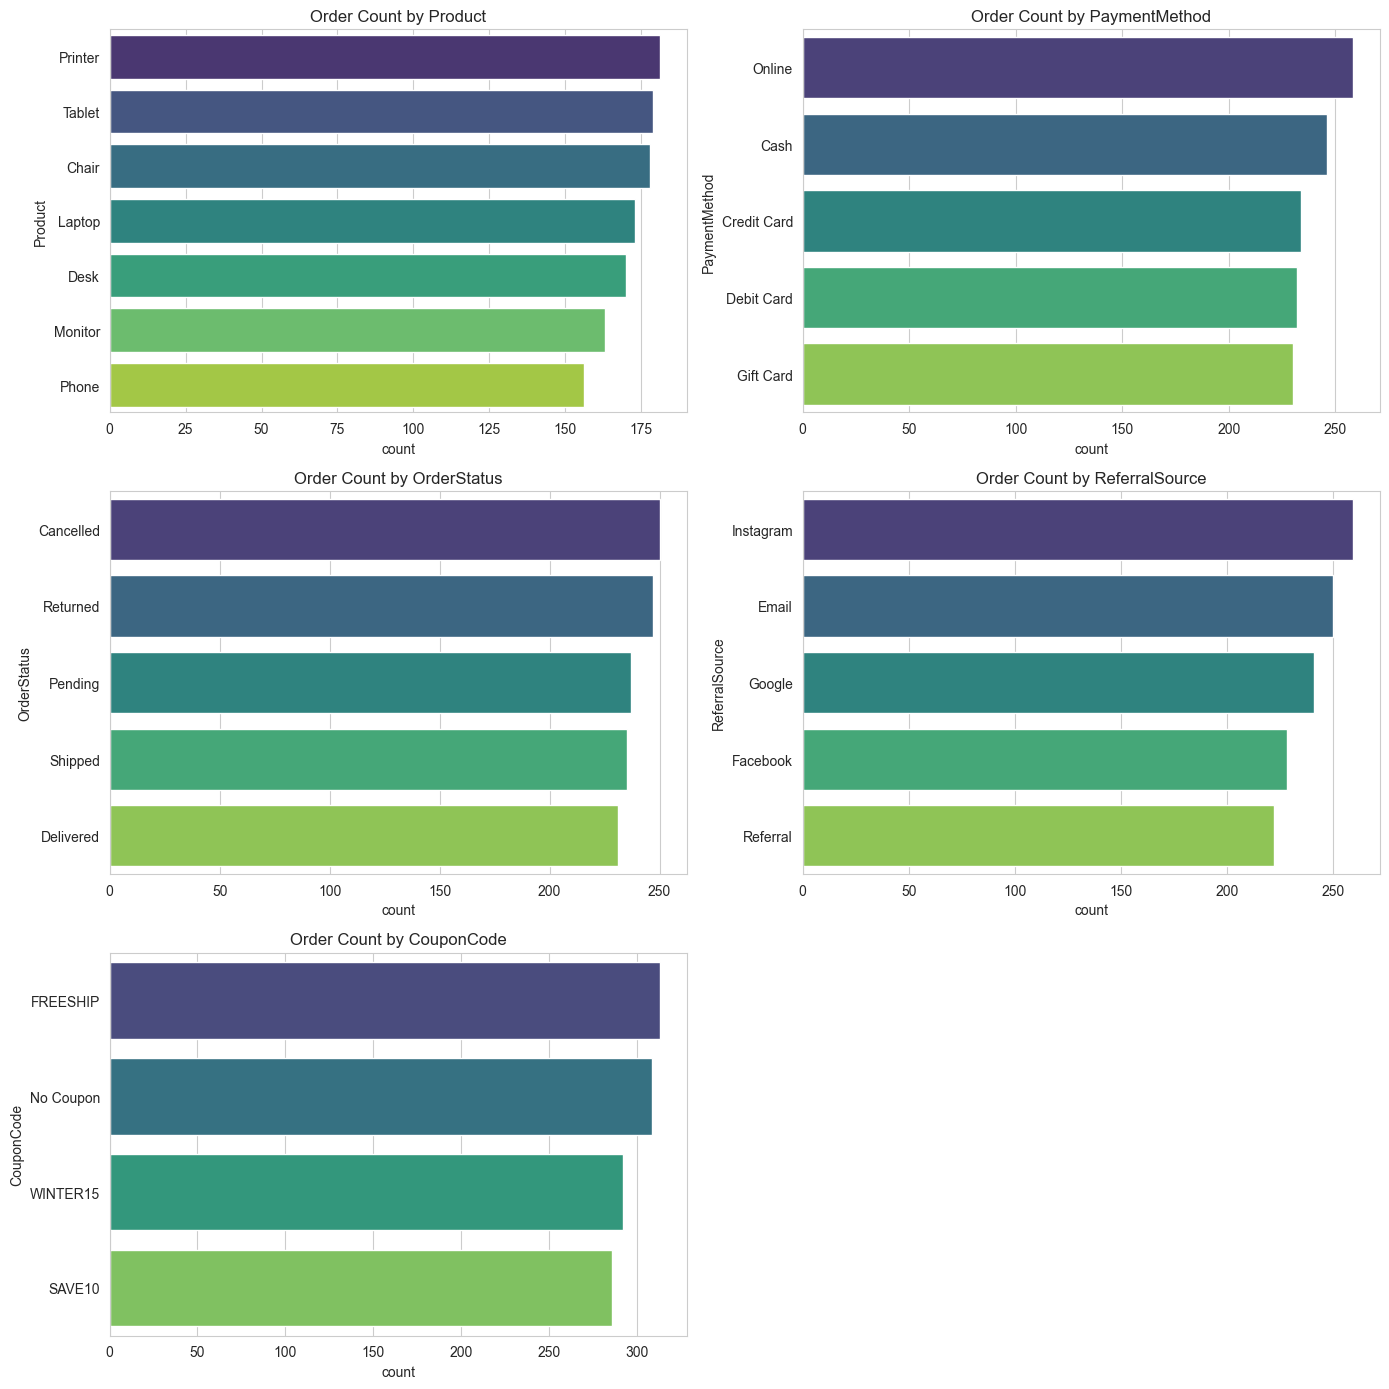

In [15]:
categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Order Count by {col}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [16]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
    print()

--- Product ---
Product
Printer    15.1%
Tablet     14.9%
Chair      14.8%
Laptop     14.4%
Desk       14.2%
Monitor    13.6%
Phone      13.0%
Name: proportion, dtype: object

--- PaymentMethod ---
PaymentMethod
Online         21.5%
Cash           20.5%
Credit Card    19.5%
Debit Card     19.3%
Gift Card      19.2%
Name: proportion, dtype: object

--- OrderStatus ---
OrderStatus
Cancelled    20.8%
Returned     20.6%
Pending      19.8%
Shipped      19.6%
Delivered    19.2%
Name: proportion, dtype: object

--- ReferralSource ---
ReferralSource
Instagram    21.6%
Email        20.8%
Google       20.1%
Facebook     19.0%
Referral     18.5%
Name: proportion, dtype: object

--- CouponCode ---
CouponCode
FREESHIP     26.1%
No Coupon    25.8%
WINTER15     24.3%
SAVE10       23.8%
Name: proportion, dtype: object



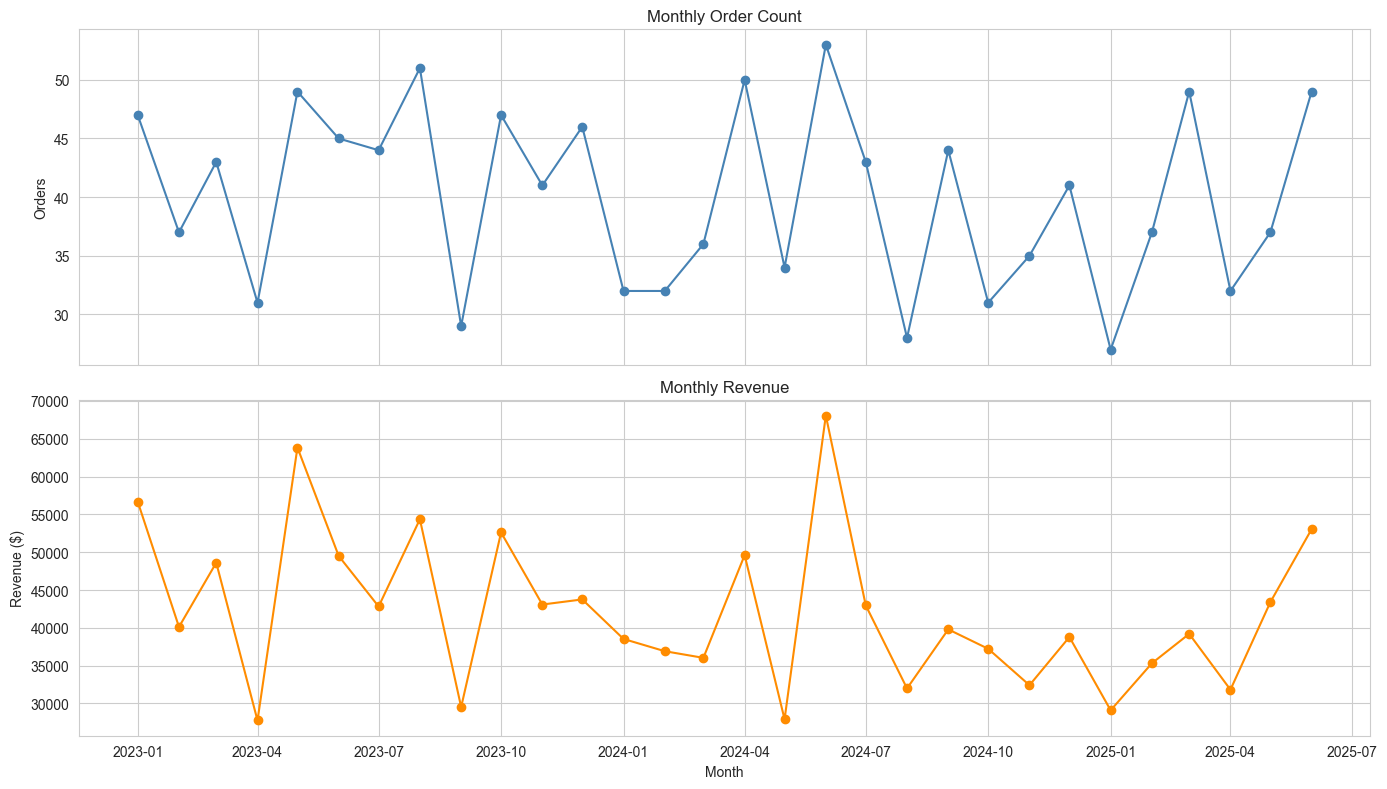

In [17]:
monthly_trend = df.groupby(df['Date'].dt.to_period('M')).agg(
    OrderCount=('OrderID', 'count'),
    TotalRevenue=('TotalPrice', 'sum')
).reset_index()
monthly_trend['Date'] = monthly_trend['Date'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly_trend['Date'], monthly_trend['OrderCount'], marker='o', color='steelblue')
axes[0].set_title('Monthly Order Count')
axes[0].set_ylabel('Orders')

axes[1].plot(monthly_trend['Date'], monthly_trend['TotalRevenue'], marker='o', color='darkorange')
axes[1].set_title('Monthly Revenue')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

C:\Users\SAIM\AppData\Local\Temp\ipykernel_16184\415698355.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_counts.index, y=dow_counts.values, palette='crest')


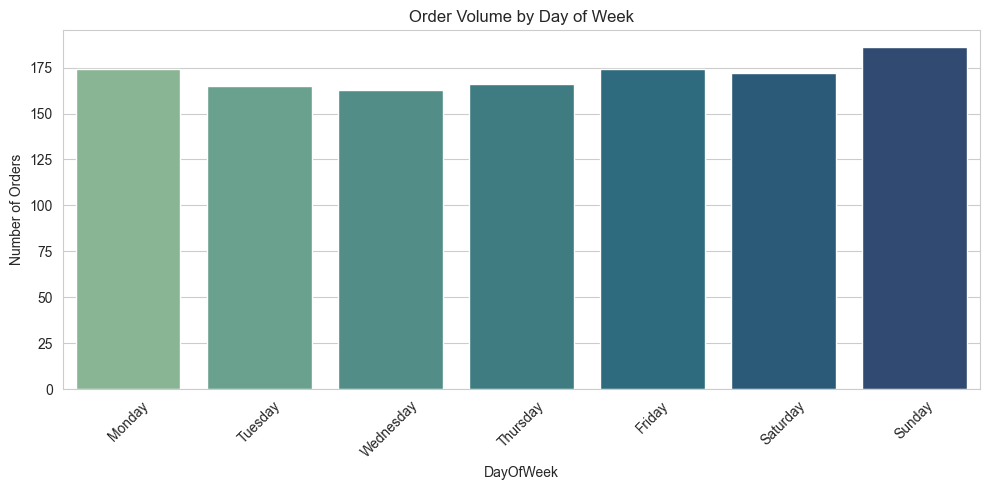

In [18]:
# Order volume by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['DayOfWeek'].value_counts().reindex(dow_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_counts.index, y=dow_counts.values, palette='crest')
plt.title('Order Volume by Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

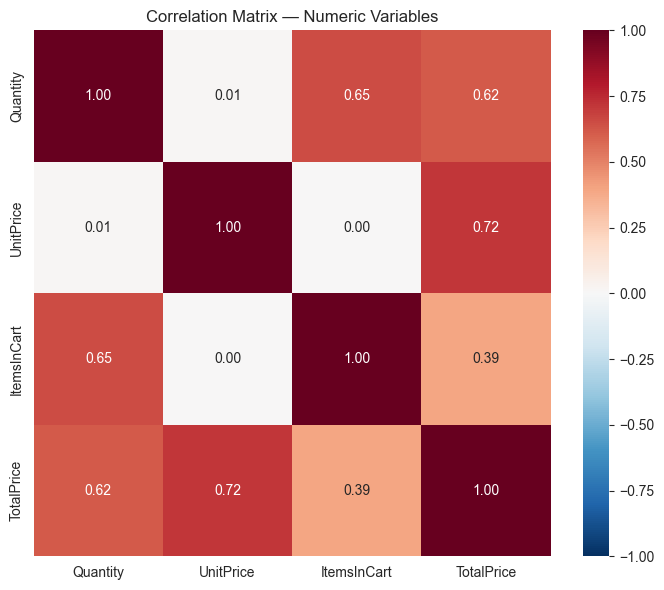

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


In [19]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()

corr_matrix

In [20]:
revenue_by_product = df.groupby('Product')['TotalPrice'].agg(['sum', 'mean', 'count']) \
                        .rename(columns={'sum': 'TotalRevenue', 'mean': 'AvgOrderValue', 'count': 'OrderCount'}) \
                        .sort_values('TotalRevenue', ascending=False)
revenue_by_product['RevenueShare %'] = (revenue_by_product['TotalRevenue'] / revenue_by_product['TotalRevenue'].sum() * 100).round(1)
revenue_by_product

,TotalRevenue,AvgOrderValue,OrderCount,RevenueShare %
Product,,,,
Chair,195620.11,1098.989382,178,15.5
Printer,195612.61,1080.732652,181,15.5
Laptop,192126.56,1110.558150,173,15.2
Tablet,186568.95,1042.284637,179,14.8
Monitor,175651.41,1077.616012,163,13.9
Desk,167459.93,985.058412,170,13.2
Phone,151722.39,972.579423,156,12.0


C:\Users\SAIM\AppData\Local\Temp\ipykernel_16184\2185377431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_product['TotalRevenue'], y=revenue_by_product.index, palette='mako')


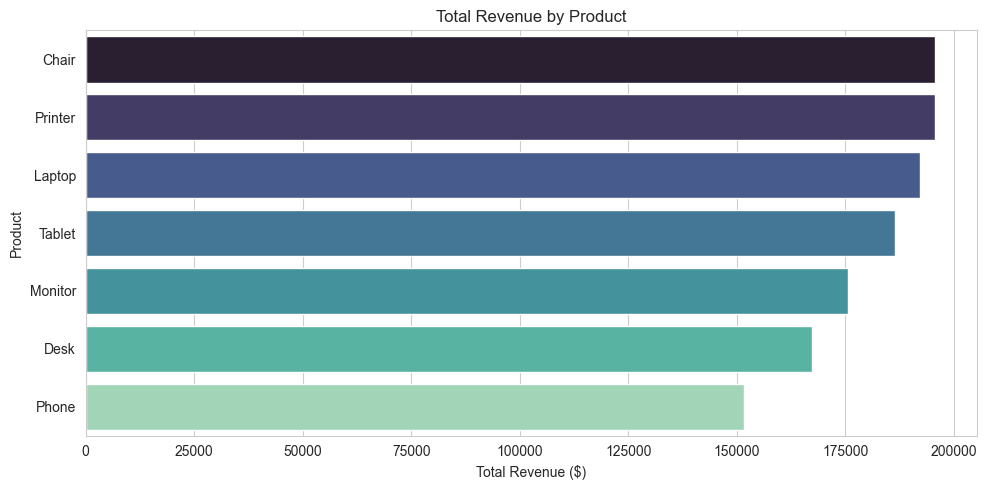

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x=revenue_by_product['TotalRevenue'], y=revenue_by_product.index, palette='mako')
plt.title('Total Revenue by Product')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

In [22]:
status_summary = df.groupby('OrderStatus').agg(
    OrderCount=('OrderID', 'count'),
    TotalValue=('TotalPrice', 'sum')
).sort_values('OrderCount', ascending=False)
status_summary['Share %'] = (status_summary['OrderCount'] / status_summary['OrderCount'].sum() * 100).round(1)
status_summary

,OrderCount,TotalValue,Share %
OrderStatus,,,
Cancelled,250,276396.21,20.8
Returned,247,243277.70,20.6
Pending,237,256328.15,19.8
Shipped,235,246159.58,19.6
Delivered,231,242600.32,19.2


In [23]:
payment_summary = df.groupby('PaymentMethod')['TotalPrice'].agg(['count', 'mean', 'sum']) \
                       .rename(columns={'count': 'OrderCount', 'mean': 'AvgOrderValue', 'sum': 'TotalRevenue'}) \
                       .sort_values('TotalRevenue', ascending=False)
payment_summary

,OrderCount,AvgOrderValue,TotalRevenue
PaymentMethod,,,
Credit Card,234,1127.553974,263847.63
Online,258,1017.220698,262442.94
Cash,246,1056.041829,259786.29
Gift Card,230,1070.973565,246323.92
Debit Card,232,1001.556810,232361.18


In [24]:
top_product = revenue_by_product['TotalRevenue'].idxmax()
top_product_share = revenue_by_product.loc[top_product, 'RevenueShare %']
cancel_return_pct = status_summary.loc[status_summary.index.isin(['Cancelled', 'Returned']), 'Share %'].sum()
skew_col = 'TotalPrice'
skew_note = "right-skewed" if df[skew_col].mean() > df[skew_col].median() else "left-skewed"

print("KEY FINDINGS")
print("=" * 60)
print(f"1. Dataset covers {df['Date'].min().date()} to {df['Date'].max().date()} ({len(df)} orders).")
print(f"2. Top revenue-generating product: {top_product} ({top_product_share}% of total revenue).")
print(f"3. TotalPrice distribution is {skew_note} -> median is a safer 'typical order value' than mean.")
print(f"4. Combined Cancelled + Returned orders: {cancel_return_pct:.1f}% of all orders.")
print(f"5. Outliers detected in TotalPrice: {outlier_report['TotalPrice']} orders "
      f"(likely large legitimate bulk purchases, not necessarily errors — worth a manual review).")
print(f"6. No missing data issues remain after treating CouponCode nulls as 'No Coupon' (0% of dataset had system errors).")

KEY FINDINGS
1. Dataset covers 2023-01-01 to 2025-06-30 (1200 orders).
2. Top revenue-generating product: Chair (15.5% of total revenue).
3. TotalPrice distribution is right-skewed -> median is a safer 'typical order value' than mean.
4. Combined Cancelled + Returned orders: 41.4% of all orders.
5. Outliers detected in TotalPrice: 8 orders (likely large legitimate bulk purchases, not necessarily errors — worth a manual review).
6. No missing data issues remain after treating CouponCode nulls as 'No Coupon' (0% of dataset had system errors).
